In [41]:
import pandas as pd
file=pd.read_csv(r"E:\vs\assignment_1\house_price\BostonHousing.csv")

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv(r"E:\vs\assignment_1\house_price\BostonHousing.csv")

print("Shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()

Shape: (506, 14)
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  501.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695  

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [44]:
X = df.drop("medv", axis=1)
y = df["medv"]

print("Features:", X.columns.tolist())
print("Target: medv")

Features: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
Target: medv


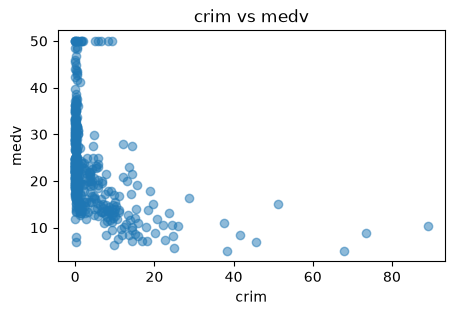

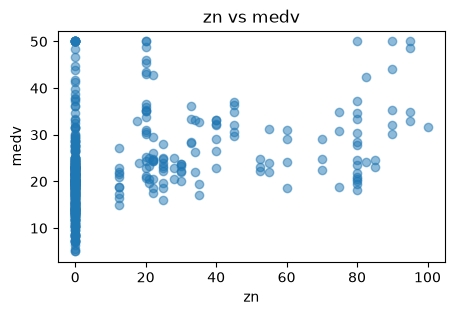

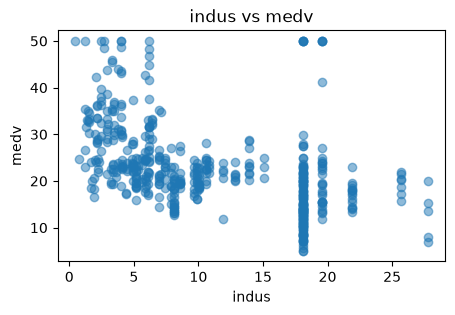

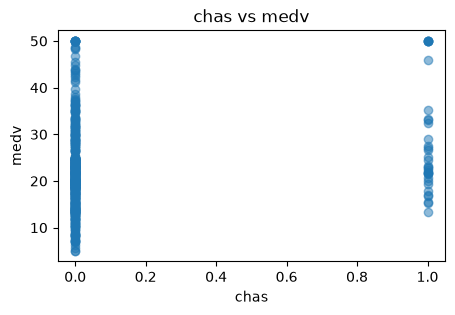

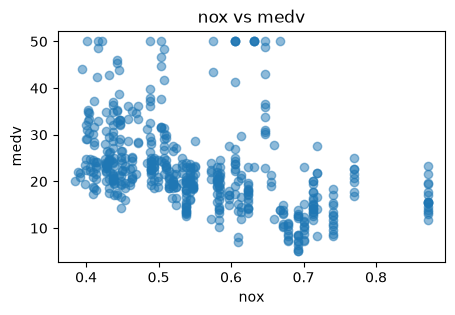

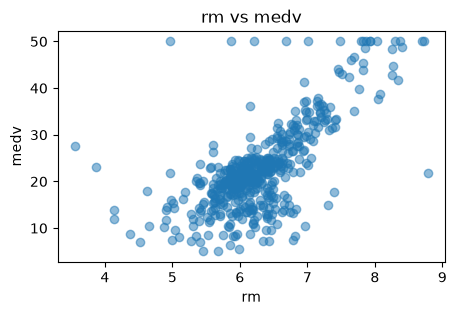

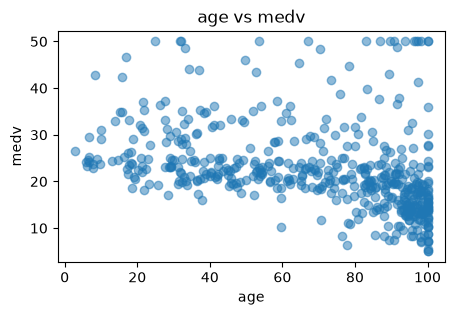

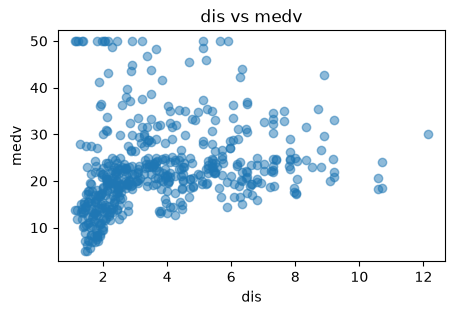

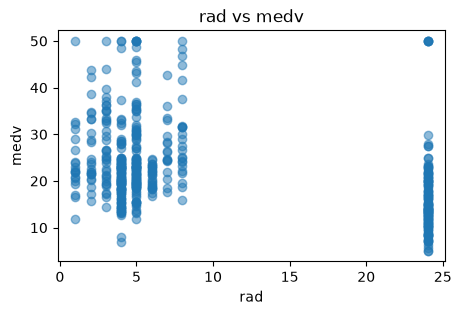

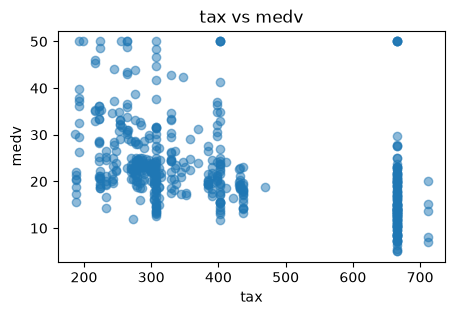

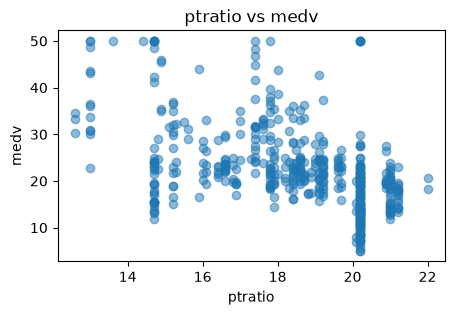

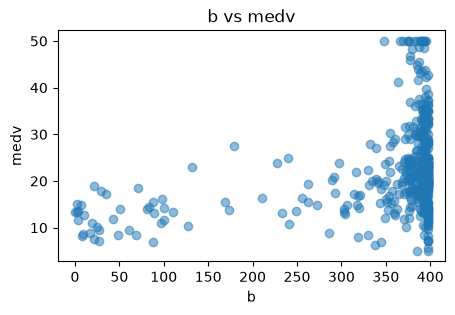

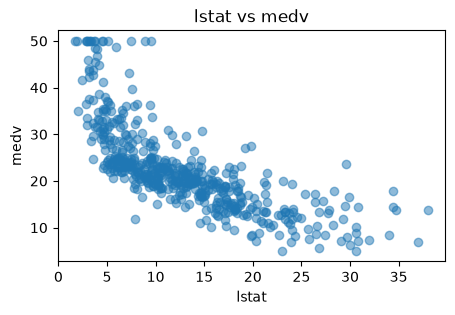

In [45]:
for column in X.columns:
    plt.figure(figsize=(5, 3))
    plt.scatter(X[column], y, alpha=0.5)
    plt.xlabel(column)
    plt.ylabel("medv")
    plt.title(f"{column} vs medv")
    plt.show()

In [46]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Training: 303
Validation: 101
Test: 102


In [47]:
print("Mean")
display(df.mean(numeric_only=True))

print("Standard deviation")
display(df.std(numeric_only=True))

print("Correlation with medv")
display(df.corr(numeric_only=True)["medv"].sort_values(ascending=False))

Mean


crim         3.613524
zn          11.363636
indus       11.136779
chas         0.069170
nox          0.554695
rm           6.284341
age         68.574901
dis          3.795043
rad          9.549407
tax        408.237154
ptratio     18.455534
b          356.674032
lstat       12.653063
medv        22.532806
dtype: float64

Standard deviation


crim         8.601545
zn          23.322453
indus        6.860353
chas         0.253994
nox          0.115878
rm           0.705587
age         28.148861
dis          2.105710
rad          8.707259
tax        168.537116
ptratio      2.164946
b           91.294864
lstat        7.141062
medv         9.197104
dtype: float64

Correlation with medv


medv       1.000000
rm         0.696169
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

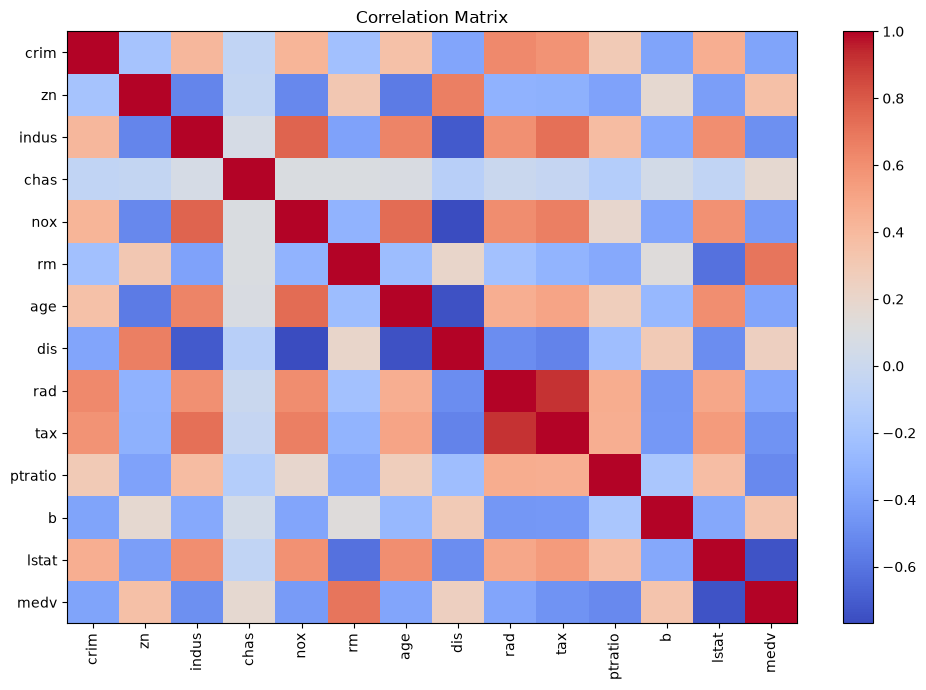

In [48]:
plt.figure(figsize=(10, 7))

plt.imshow(df.corr(numeric_only=True), cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
X = df.drop("medv", axis=1).copy()
y = df["medv"].copy()

# Convert every feature to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# Replace missing values with median
X = X.fillna(X.median())

# Split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# Convert to NumPy
X_train_np = X_train.to_numpy(dtype=float)
X_val_np = X_val.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

y_train_np = y_train.to_numpy(dtype=float)
y_val_np = y_val.to_numpy(dtype=float)
y_test_np = y_test.to_numpy(dtype=float)

# Calculate scaling values
mean = np.mean(X_train_np, axis=0)
std = np.std(X_train_np, axis=0)

# Prevent division by zero
std[std == 0] = 1

# Scale
X_train_scaled = (X_train_np - mean) / std
X_val_scaled = (X_val_np - mean) / std
X_test_scaled = (X_test_np - mean) / std

print("NaN:", np.isnan(X_train_scaled).sum())
print("Inf:", np.isinf(X_train_scaled).sum())

NaN: 0
Inf: 0


In [50]:
X_train_np = X_train.values.astype(float)
X_val_np = X_val.values.astype(float)
X_test_np = X_test.values.astype(float)

y_train_np = y_train.values.astype(float)
y_val_np = y_val.values.astype(float)
y_test_np = y_test.values.astype(float)

mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)

std[std == 0] = 1

X_train_scaled = (X_train_np - mean) / std
X_val_scaled = (X_val_np - mean) / std
X_test_scaled = (X_test_np - mean) / std

In [51]:
X_train_gd = np.c_[np.ones(len(X_train_scaled)), X_train_scaled]
X_val_gd = np.c_[np.ones(len(X_val_scaled)), X_val_scaled]
X_test_gd = np.c_[np.ones(len(X_test_scaled)), X_test_scaled]

In [52]:
def gradient_descent(X, y, learning_rate=0.001, iterations=5000):
    m = len(y)
    weights = np.zeros(X.shape[1])
    cost_history = []

    for i in range(iterations):
        predictions = X @ weights
        error = predictions - y

        cost = np.mean(error ** 2) / 2
        cost_history.append(cost)

        gradient = (X.T @ error) / m
        weights = weights - learning_rate * gradient

    return weights, cost_history

In [53]:
start = time.time()

gd_weights, cost_history = gradient_descent(
    X_train_gd,
    y_train_np,
    learning_rate=0.001,
    iterations=5000
)

gd_time = time.time() - start

print("Training time:", gd_time)
print("Weights:", gd_weights)

Training time: 0.18142390251159668
Weights: [22.6411858  -0.60854966  0.36626501 -0.1264183   0.85865655 -1.23357431
  3.74852625  0.11989689 -2.17788763  0.5130406  -0.44760324 -1.78314023
  1.32904664 -3.35143706]


In [54]:
gd_train_pred = X_train_gd @ gd_weights
gd_val_pred = X_val_gd @ gd_weights
gd_test_pred = X_test_gd @ gd_weights

gd_train_mse = mean_squared_error(y_train_np, gd_train_pred)
gd_val_mse = mean_squared_error(y_val_np, gd_val_pred)
gd_test_mse = mean_squared_error(y_test_np, gd_test_pred)

print("Train MSE:", gd_train_mse)
print("Validation MSE:", gd_val_mse)
print("Test MSE:", gd_test_mse)

Train MSE: 22.265695258070618
Validation MSE: 23.008796520783743
Test MSE: 27.259731592110708


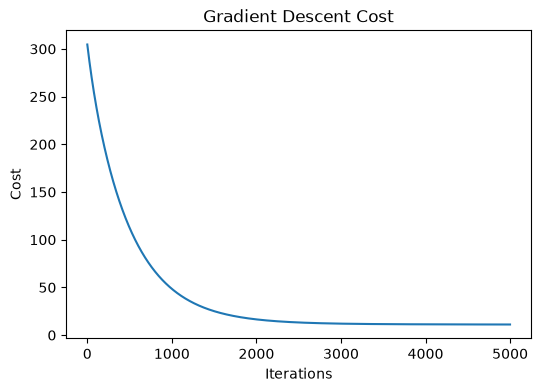

In [55]:
plt.figure(figsize=(6, 4))

plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost")

plt.show()

In [56]:
def normal_equation(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

In [57]:
start = time.time()

normal_weights = normal_equation(
    X_train_gd,
    y_train_np
)

normal_time = time.time() - start

print("Training time:", normal_time)
print("Weights:", normal_weights)

Training time: 0.0040132999420166016
Weights: [22.79438944 -0.84821511  0.79716122  0.34936392  0.80863125 -2.2642016
  3.48172823  0.05739121 -3.22946256  1.73148172 -1.46617931 -2.0181712
  1.29057503 -3.42185523]


In [58]:
normal_train_pred = X_train_gd @ normal_weights
normal_val_pred = X_val_gd @ normal_weights
normal_test_pred = X_test_gd @ normal_weights

normal_train_mse = mean_squared_error(y_train_np, normal_train_pred)
normal_val_mse = mean_squared_error(y_val_np, normal_val_pred)
normal_test_mse = mean_squared_error(y_test_np, normal_test_pred)

print("Train MSE:", normal_train_mse)
print("Validation MSE:", normal_val_mse)
print("Test MSE:", normal_test_mse)

Train MSE: 21.653211833648776
Validation MSE: 22.374318327204207
Test MSE: 25.510857040640147


In [59]:
comparison = pd.DataFrame({
    "Method": ["Gradient Descent", "Normal Equation"],
    "Training Time": [gd_time, normal_time],
    "Train MSE": [gd_train_mse, normal_train_mse],
    "Validation MSE": [gd_val_mse, normal_val_mse],
    "Test MSE": [gd_test_mse, normal_test_mse]
})

comparison

,Method,Training Time,Train MSE,Validation MSE,Test MSE
0,Gradient Descent,0.181424,22.265695,23.008797,27.259732
1,Normal Equation,0.004013,21.653212,22.374318,25.510857


In [60]:
weight_comparison = pd.DataFrame({
    "Feature": ["Intercept"] + X.columns.tolist(),
    "Gradient Descent": gd_weights,
    "Normal Equation": normal_weights
})

weight_comparison

,Feature,Gradient Descent,Normal Equation
0,Intercept,22.641186,22.794389
1,crim,-0.608550,-0.848215
2,zn,0.366265,0.797161
3,indus,-0.126418,0.349364
4,chas,0.858657,0.808631
5,nox,-1.233574,-2.264202
6,rm,3.748526,3.481728
7,age,0.119897,0.057391
8,dis,-2.177888,-3.229463
9,rad,0.513041,1.731482


In [61]:
degrees = [1, 2, 3, 5]

train_errors = []
validation_errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train_np)

    train_pred = model.predict(X_train_poly)
    val_pred = model.predict(X_val_poly)

    train_mse = mean_squared_error(y_train_np, train_pred)
    val_mse = mean_squared_error(y_val_np, val_pred)

    train_errors.append(train_mse)
    validation_errors.append(val_mse)

    print(
        "Degree:", degree,
        "| Train MSE:", round(train_mse, 3),
        "| Validation MSE:", round(val_mse, 3)
    )

Degree: 1 | Train MSE: 21.653 | Validation MSE: 22.374
Degree: 2 | Train MSE: 3.465 | Validation MSE: 20.663
Degree: 3 | Train MSE: 0.0 | Validation MSE: 1818.173
Degree: 5 | Train MSE: 0.0 | Validation MSE: 4922.595


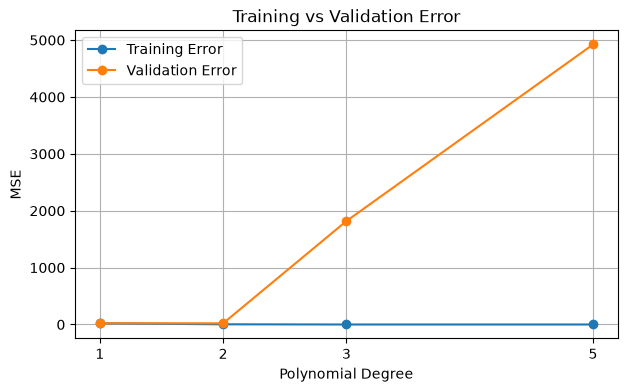

In [62]:
plt.figure(figsize=(7, 4))

plt.plot(degrees, train_errors, marker="o", label="Training Error")
plt.plot(degrees, validation_errors, marker="o", label="Validation Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Validation Error")
plt.xticks(degrees)
plt.legend()
plt.grid(True)

plt.show()

In [63]:
best_index = np.argmin(validation_errors)
best_degree = degrees[best_index]

print("Best degree:", best_degree)
print("Lowest validation MSE:", validation_errors[best_index])

Best degree: 2
Lowest validation MSE: 20.662915378102117


In [64]:
training_sizes = [50, 100, 200, 300, 400]

learning_train_errors = []
learning_val_errors = []

for size in training_sizes:
    X_subset = X_train_scaled[:size]
    y_subset = y_train_np[:size]

    model = LinearRegression()
    model.fit(X_subset, y_subset)

    train_pred = model.predict(X_subset)
    val_pred = model.predict(X_val_scaled)

    train_mse = mean_squared_error(y_subset, train_pred)
    val_mse = mean_squared_error(y_val_np, val_pred)

    learning_train_errors.append(train_mse)
    learning_val_errors.append(val_mse)

    print(
        "Samples:", size,
        "| Train MSE:", round(train_mse, 3),
        "| Validation MSE:", round(val_mse, 3)
    )

Samples: 50 | Train MSE: 19.17 | Validation MSE: 40.703
Samples: 100 | Train MSE: 24.48 | Validation MSE: 26.228
Samples: 200 | Train MSE: 24.251 | Validation MSE: 23.24
Samples: 300 | Train MSE: 21.834 | Validation MSE: 22.366
Samples: 400 | Train MSE: 21.653 | Validation MSE: 22.374


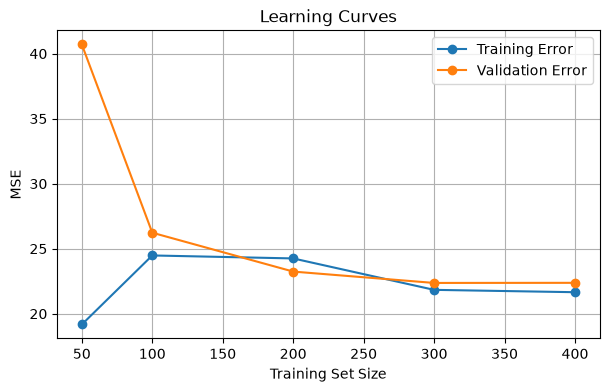

In [65]:
plt.figure(figsize=(7, 4))

plt.plot(
    training_sizes,
    learning_train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    training_sizes,
    learning_val_errors,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.title("Learning Curves")
plt.legend()
plt.grid(True)

plt.show()

In [66]:
final_model = LinearRegression()

final_model.fit(X_train_scaled, y_train_np)

predictions = final_model.predict(X_test_scaled)

mse = mean_squared_error(y_test_np, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, predictions)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MSE: 25.510857040640055
Test RMSE: 5.050827361991306
Test R²: 0.6521268105742206


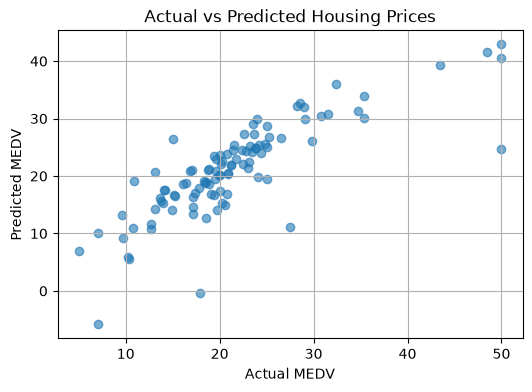

In [67]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test_np, predictions, alpha=0.6)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted Housing Prices")
plt.grid(True)

plt.show()